In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# vi = Table.read('/global/cfs/cdirs/desi/sv/vi/TruthTables/Fuji/LRG/220505_LRG_SV1_blanc_and_Fuji_v1.csv')
vi = Table.read('/Users/rongpu/Documents/Data/desi_targets/lrg_paper/220505_LRG_SV1_blanc_and_Fuji_v1.csv')

In [4]:
vi[:5]

TARGETID,TILEID,FIBER,TARGET_RA,TARGET_DEC,best_z,best_quality,best_spectype,all_VI_comments,merger_comment,VI_version,GAIA_PHOT_G_MEAN_MAG,FIBERFLUX_R,FLUX_R,FIBERFLUX_Z,FIBERFLUX_G,FLUX_W1,FLUX_G,FLUX_Z,EBV,ZWARN,PHOTSYS,MASKBITS,Redrock_z,zmag,gmag,rmag,GTOT,GFIB,RFIB,ZFIB,W1,RZ,GR,ZW1,RW1
int64,int64,int64,float64,float64,float64,float64,str6,str189,str54,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str4,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627634551824898,80605,398,36.18946453136912,-6.149115843122294,0.355,4.0,GALAXY,b'N/A',b'none',Blanc,0.0,5.7867155,21.593157,13.023925,1.1649392,74.80693,4.346976,48.598835,0.03287473,0,b'S',0,0.35496393006020327,18.243624,20.798872,19.093035,20.798872,22.228582,20.522745,19.673334,17.809097,0.849411,1.7058372,0.43452644,1.2839375
39627634556014086,80605,353,36.291054274191865,-6.127697503907206,0.6555,4.0,GALAXY,b'N/A',b'none',Blanc,0.0,0.814184,1.8871921,3.0356867,0.14244623,26.712502,0.33017525,7.0364,0.032857675,0,b'S',0,0.6555704448517184,20.341833,23.597534,21.739323,23.597534,24.510267,22.652058,21.254566,18.927168,1.3974895,1.8582115,1.4146652,2.8121548
39627634556015764,80605,191,36.33448600336392,-6.150640067188368,0.7977,4.0,GALAXY,b'N/A',b'none',Blanc,0.0,0.68678916,1.4611111,3.7292135,0.111301824,31.963188,0.2367893,7.9337234,0.032773368,0,b'S',0,0.7976843246338589,20.211618,23.958761,22.017336,23.958761,24.77841,22.836987,21.03127,18.732344,1.8057175,1.9414253,1.4792747,3.2849922
39627634556017139,80605,495,36.3744308172597,-6.156238417732969,2.4982,3.0,QSO,Something weird? Broad absorption line quasar (BAL) Many absorption lines,Lyman alpha,Fuji,0.0,3.2941136,4.229547,11.751681,0.390169,28.320358,0.5009658,15.08882,0.03307127,0,b'S',0,0.4882,19.513313,23.14419,20.862665,23.14419,23.415577,21.134054,19.7847,18.863668,1.3493519,2.2815247,0.64964485,1.9989967
39627634556018800,80605,485,36.418824857534716,-6.197608931100611,0.6995,3.5,GALAXY,b'N/A',b'none',Blanc,0.0,0.6638721,1.6235851,3.0128665,0.10467312,16.873074,0.25599164,7.3683543,0.033932373,0,b'S',0,0.6994398147311552,20.290482,23.870377,21.900349,23.870377,24.841354,22.871326,21.26146,19.425772,1.6098671,1.9700279,0.86470985,2.474577


In [5]:
print(len(vi), len(np.unique(vi['TARGETID'])))

3562 3561


In [6]:
tmp = Table()
tmp['type'], tmp['count'] = np.unique(vi['TILEID'], return_counts=True)
tmp

type,count
int64,int64
80605,1773
80609,1789


In [7]:
tmp = Table()
tmp['type'], tmp['count'] = np.unique(vi['VI_version'], return_counts=True)
tmp

type,count
str5,int64
Blanc,3431
Fuji,131


In [8]:
good = vi['best_quality']>=2.5
print(np.sum(~good)/len(good))

0.01347557551937114


---------

In [9]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

mask = cat['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Remove QSO targets
# mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
# print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove objects classified as STARs
mask = cat['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= (cat['Z']<1.5)
cat['q'] &= cat['DELTACHI2']>15

mask = np.in1d(cat['TARGETID'], vi['TARGETID'])
print(np.sum(mask), len(np.unique(cat['TARGETID'][mask])))
cat = cat[mask]

cat = join(cat, vi[['TARGETID', 'best_z', 'best_quality', 'VI_version']], keys='TARGETID', join_type='left')
print(len(cat), len(np.unique(cat['TARGETID'])))

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove objects classified as QSOs: 40125 1215 0.02939042089985486
Remove objects classified as STARs: 39668 457 0.011389408099688473
39533 39533
3304 3304
3305 3304


In [11]:
print('VI redshift disagreeing with redrock redshift:')
zdiff_threshold = 0.0033
mask_diff = np.abs((cat['best_z'] - cat['Z'])/(1 + cat['Z'])) > zdiff_threshold
mask = (cat['best_quality']>=2.5) & cat['q']
print('{:.2f}% ({}/{})'.format(100*np.sum(mask & mask_diff)/np.sum(mask), np.sum(mask & mask_diff), np.sum(mask)))
mask &= cat['main_lrg'].copy()
print('{:.2f}% ({}/{})'.format(100*np.sum(mask & mask_diff)/np.sum(mask), np.sum(mask & mask_diff), np.sum(mask)))

VI redshift disagreeing with redrock redshift:
0.74% (24/3261)
0.35% (3/866)


In [12]:
print('Fraction of VI uncertain redshifts in all SV LRGs:')
mask0 = np.full(len(cat), True)
mask = mask0 & (cat['best_quality']<2.5)
print('{:.2f}% ({}/{})'.format(100*np.sum(mask)/np.sum(mask0), np.sum(mask), np.sum(mask0)))

print('Fraction of VI uncertain redshifts in Main LRGs:')
mask0 = cat['main_lrg'].copy()
mask = mask0 & (cat['best_quality']<2.5)
print('{:.2f}% ({}/{})'.format(100*np.sum(mask)/np.sum(mask0), np.sum(mask), np.sum(mask0)))

Fraction of VI uncertain redshifts in all SV LRGs:
1.00% (33/3305)
Fraction of VI uncertain redshifts in Main LRGs:
0.57% (5/872)


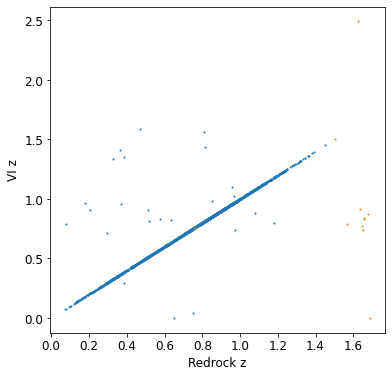

In [13]:
mask1 = (cat['best_quality']>=2.5) & cat['q']
mask2 = (cat['best_quality']>=2.5) & (~cat['q'])
plt.figure(figsize=(6, 6))
plt.plot(cat['Z'][mask1], cat['best_z'][mask1], '.', ms=2)
plt.plot(cat['Z'][mask2], cat['best_z'][mask2], '.', ms=2)
plt.xlabel('Redrock z')
plt.ylabel('VI z')
plt.show()